In [95]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import scipy
import pickle
import math
import solvers
import sde
import dnnlib
from solvers import edm_sampler

torch.manual_seed(42)

In [96]:
with dnnlib.util.open_url("model/edm2-img64-xl-0671088-0.040.pkl") as f:
    data = pickle.load(f)
model = data["ema"].to("cuda")

In [97]:
encoder = data.get('encoder', None)
if encoder is None:
    encoder = dnnlib.util.construct_class_by_name(class_name='training.encoders.StandardRGBEncoder')

In [98]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = torch.randn_like(x) 

In [99]:
labels = torch.zeros((16, 1000)).to("cuda")
for i in range(16):
    labels[i, i] = 1

In [100]:
sigma_min = 0.002
sigma_max = 80

sde_ = sde.EDMSDE().to("cuda")
rsde = sde_.get_reverse_sde(model).to("cuda")
rsde.ode = False

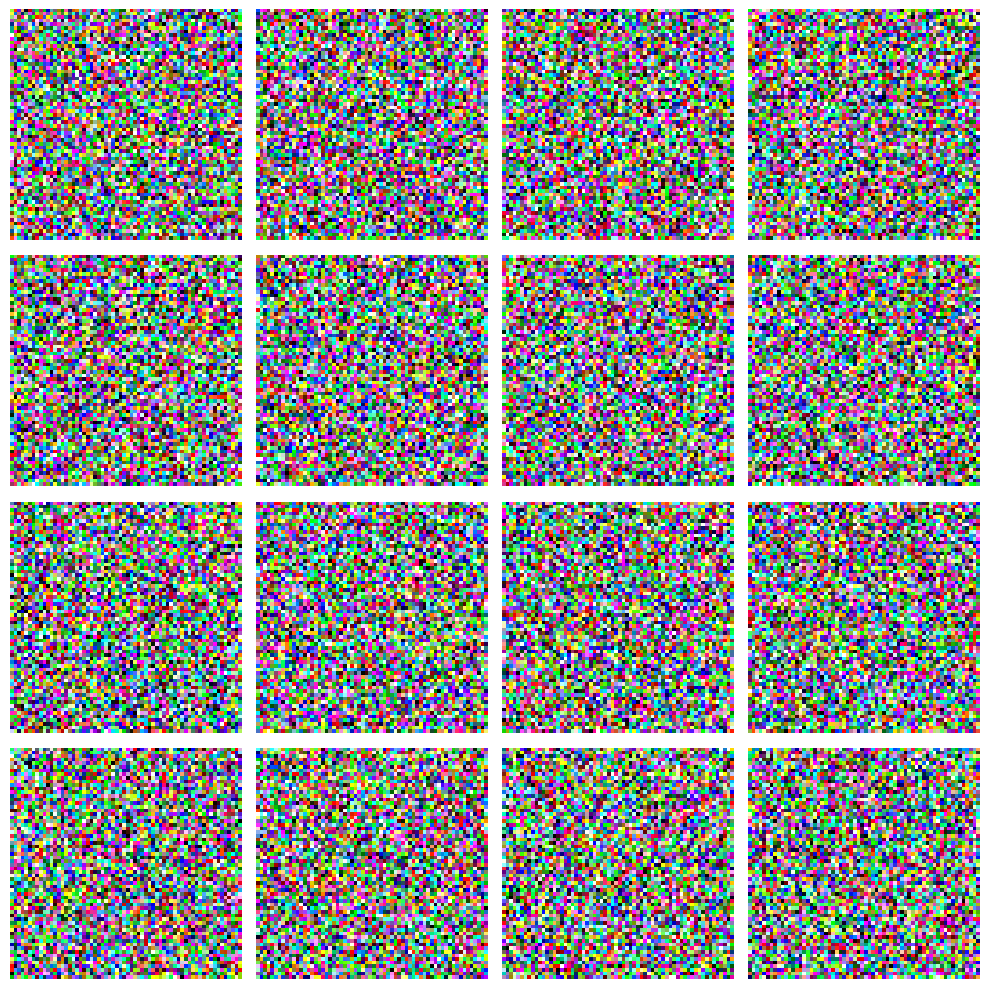

In [101]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [102]:
n_steps = 72
rho = 7
# From EDM2 code
step_indices = torch.arange(n_steps)
sigma_steps = (sigma_max ** (1 / rho) + step_indices / (n_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
discretisation = torch.cat([sigma_steps, torch.zeros_like(sigma_steps[:1])])

In [103]:
em_solver = solvers.HeunSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone(), labels)

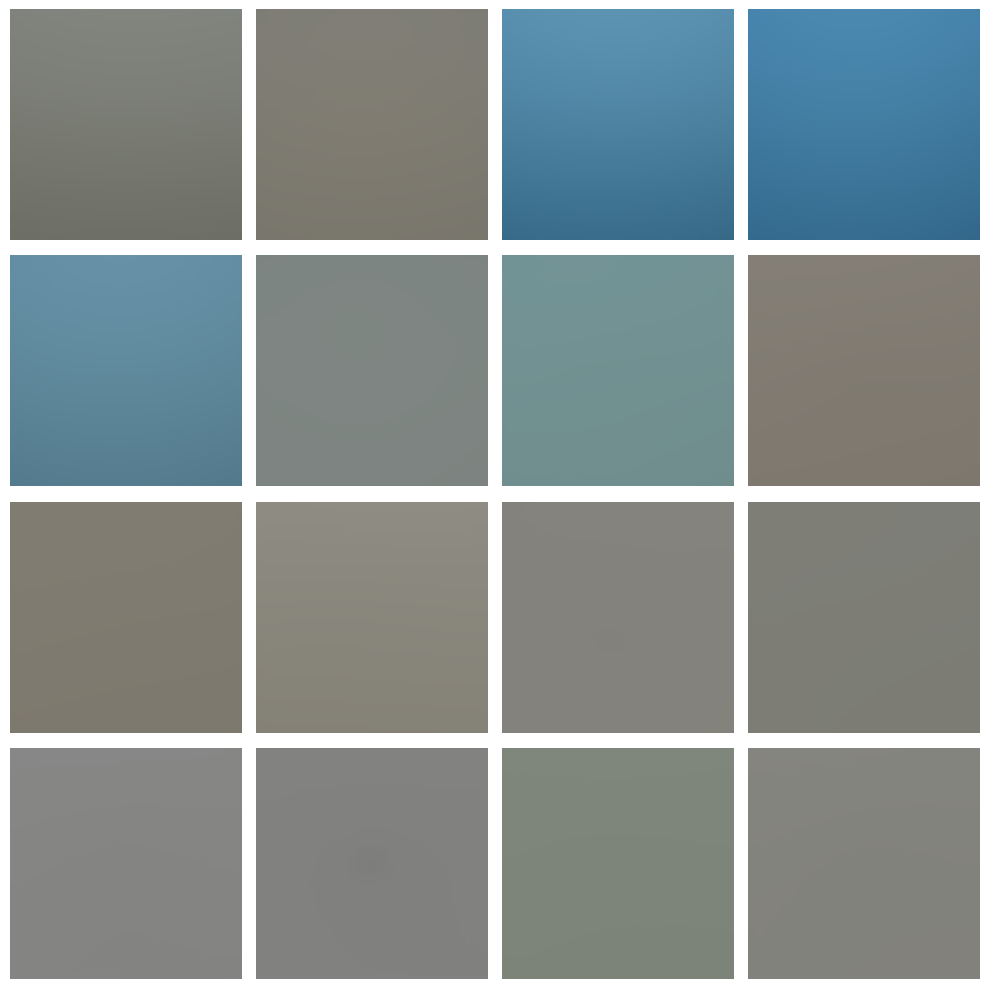

In [104]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [84]:
sigmas = []
sigmas_std = []
def pi_callback(x, t, h, error):    
    print(f"sigma = {torch.mean(t)}", end=" ")
    print(f"h = {torch.mean(h)}", end=" ")
    print(f"error = {torch.mean(error)}")
    sigmas.append(torch.mean(t).cpu())
    sigmas_std.append(torch.std(t).cpu())

In [85]:
sigmas = []
sigmas_std = []

rsde.reset_nfe()

pi_solver = solvers.PISolver(
    rsde,
    ki=0.3,
    kp=0.1, 
    tau_a=0.4,
    tau_r=3,
    alpha=0.9,
    h_start=7,
    max_decrease=0.05,
    max_increase=5,
    interval=(80, 0),
).to("cuda")

x_pi = pi_solver.solve(noise.clone(), labels, callback=pi_callback)

sigma = 73.0 h = -6.73182487487793 error = 0.43090587854385376
sigma = 66.26817321777344 h = -6.973208427429199 error = 0.3448156714439392
sigma = 59.29496383666992 h = -6.918522357940674 error = 0.3632286489009857
sigma = 52.376441955566406 h = -6.72538948059082 error = 0.38727062940597534
sigma = 45.65105438232422 h = -6.349493503570557 error = 0.4233536720275879
sigma = 39.30155944824219 h = -5.831479549407959 error = 0.46377360820770264
sigma = 33.4700813293457 h = -5.236931800842285 error = 0.5018379092216492
sigma = 28.2331485748291 h = -4.60836935043335 error = 0.5385186672210693
sigma = 23.624778747558594 h = -3.9774444103240967 error = 0.5753333568572998
sigma = 19.647335052490234 h = -3.394197940826416 error = 0.6017159223556519
sigma = 16.253135681152344 h = -2.861618995666504 error = 0.6272037625312805
sigma = 13.391517639160156 h = -2.396301746368408 error = 0.6445689797401428
sigma = 10.995216369628906 h = -1.9908236265182495 error = 0.6619499921798706
sigma = 9.004392623

In [86]:
rsde.nfe / 16

66.0

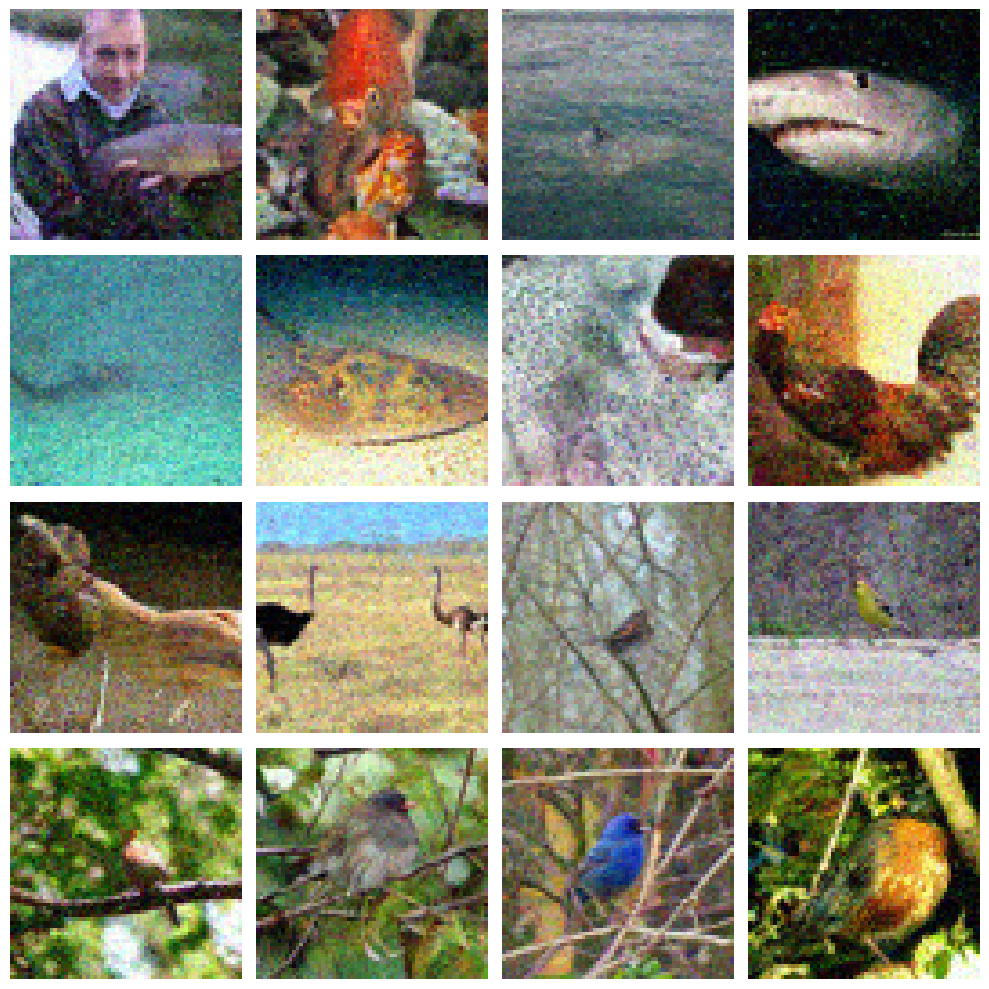

In [87]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())

Text(0, 0.5, 'sigma')

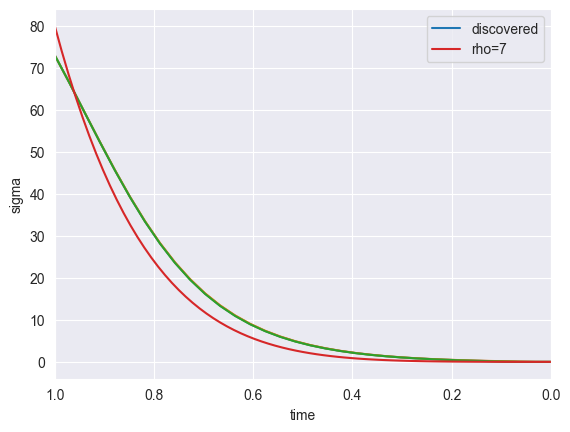

In [93]:
plt.plot(torch.linspace(1, 0, len(sigmas)), sigmas, label="discovered")
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas) + torch.tensor(sigmas_std))
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas) - torch.tensor(sigmas_std))
plt.plot(torch.linspace(1, 0, len(discretisation)), discretisation.cpu(), label="rho=7")
plt.legend()
plt.xlim(1, 0)
plt.xlabel("time")
plt.ylabel("sigma")

In [20]:
x_edm = edm_sampler(model, noise.clone(), labels)

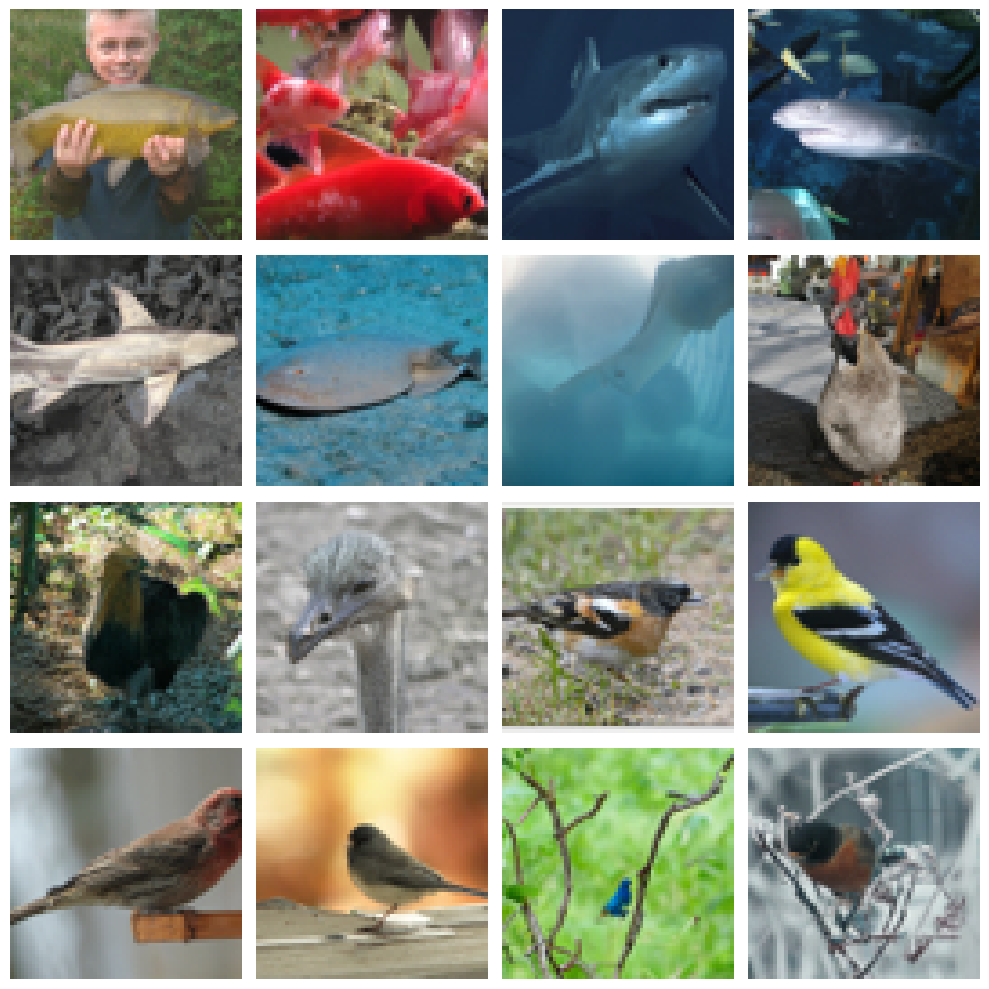

In [21]:
images = encoder.decode(x_edm).permute(0, 2, 3, 1)
plot_images(images.cpu())